In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:

county_resource_codes = {"Digby": "wpsu-7fer"}

for county, resource_code in county_resource_codes.items():
    url = f"https://data.novascotia.ca/resource/{resource_code}.csv"
    df = pd.read_csv(url)
    col = "timestamp_utc"
    timestamp_na_count = df[col].isna().sum()

    print(f"The {county} dataset has {timestamp_na_count} NA values in the {col} column.")


The Digby dataset has 0 NA values in the timestamp_utc column.


In [16]:
df.head()

,waterbody,station,lease,latitude,longitude,deployment_range,string_configuration,sensor_type,sensor_serial_number,timestamp_utc,...,dissolved_oxygen_percent_saturation,dissolved_oxygen_uncorrected_mg_per_l,salinity_psu,sensor_depth_measured_m,temperature_degree_c,qc_flag_dissolved_oxygen_percent_saturation,qc_flag_dissolved_oxygen_uncorrected_mg_per_l,qc_flag_salinity_psu,qc_flag_sensor_depth_measured_m,qc_flag_temperature_degree_c
0,St. Marys Bay,1012,1012.0,44.407102,-66.160532,2016-Jan-21 to 2016-Oct-12,surface buoy,hobo,10755237,2016-01-21T20:00:00.000,...,NaN,NaN,NaN,NaN,4.402,NaN,NaN,NaN,NaN,Not Evaluated
1,St. Marys Bay,1012,1012.0,44.407102,-66.160532,2016-Jan-21 to 2016-Oct-12,surface buoy,hobo,10755237,2016-01-24T04:00:00.000,...,NaN,NaN,NaN,NaN,2.370,NaN,NaN,NaN,NaN,Pass
2,St. Marys Bay,1012,1012.0,44.407102,-66.160532,2016-Jan-21 to 2016-Oct-12,surface buoy,hobo,10755237,2016-01-24T05:00:00.000,...,NaN,NaN,NaN,NaN,2.182,NaN,NaN,NaN,NaN,Pass
3,St. Marys Bay,1012,1012.0,44.407102,-66.160532,2016-Jan-21 to 2016-Oct-12,surface buoy,hobo,10755237,2016-01-24T06:00:00.000,...,NaN,NaN,NaN,NaN,1.994,NaN,NaN,NaN,NaN,Pass
4,St. Marys Bay,1012,1012.0,44.407102,-66.160532,2016-Jan-21 to 2016-Oct-12,surface buoy,hobo,10755237,2016-01-24T07:00:00.000,...,NaN,NaN,NaN,NaN,2.047,NaN,NaN,NaN,NaN,Pass


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   waterbody                                      1000 non-null   str    
 1   station                                        1000 non-null   str    
 2   lease                                          990 non-null    float64
 3   latitude                                       1000 non-null   float64
 4   longitude                                      1000 non-null   float64
 5   deployment_range                               1000 non-null   str    
 6   string_configuration                           1000 non-null   str    
 7   sensor_type                                    1000 non-null   str    
 8   sensor_serial_number                           1000 non-null   int64  
 9   timestamp_utc                                  1000 non-null   s

In [4]:
df.describe()

,lease,latitude,longitude,sensor_serial_number,sensor_depth_at_low_tide_m,depth_crosscheck_flag,dissolved_oxygen_percent_saturation,dissolved_oxygen_uncorrected_mg_per_l,salinity_psu,sensor_depth_measured_m,temperature_degree_c,qc_flag_dissolved_oxygen_percent_saturation,qc_flag_dissolved_oxygen_uncorrected_mg_per_l,qc_flag_salinity_psu,qc_flag_sensor_depth_measured_m
count,990.0,1000.000000,1000.000000,1.000000e+03,1000.0,0.0,0.0,0.0,0.0,0.0,1000.000000,0.0,0.0,0.0,0.0
mean,1012.0,44.406899,-66.160369,1.075524e+07,1.0,NaN,NaN,NaN,NaN,NaN,3.019425,NaN,NaN,NaN,NaN
std,0.0,0.002017,0.001622,1.393679e+00,0.0,NaN,NaN,NaN,NaN,NaN,0.584503,NaN,NaN,NaN,NaN
min,1012.0,44.386837,-66.160532,1.075524e+07,1.0,NaN,NaN,NaN,NaN,NaN,1.697000,NaN,NaN,NaN,NaN
25%,1012.0,44.407102,-66.160532,1.075524e+07,1.0,NaN,NaN,NaN,NaN,NaN,2.584000,NaN,NaN,NaN,NaN
50%,1012.0,44.407102,-66.160532,1.075524e+07,1.0,NaN,NaN,NaN,NaN,NaN,2.956000,NaN,NaN,NaN,NaN
75%,1012.0,44.407102,-66.160532,1.075524e+07,1.0,NaN,NaN,NaN,NaN,NaN,3.360500,NaN,NaN,NaN,NaN
max,1012.0,44.407102,-66.144241,1.075525e+07,1.0,NaN,NaN,NaN,NaN,NaN,4.792000,NaN,NaN,NaN,NaN


In [5]:
df.describe(include='str')

,waterbody,station,deployment_range,string_configuration,sensor_type,timestamp_utc,qc_flag_temperature_degree_c
count,1000,1000,1000,1000,1000,1000,1000
unique,1,2,1,1,1,990,3
top,St. Marys Bay,1012,2016-Jan-21 to 2016-Oct-12,surface buoy,hobo,2016-02-08T16:00:00.000,Pass
freq,1000,990,1000,1000,1000,2,982


In [28]:
df['timestamp'] = pd.to_datetime(df['timestamp_utc'])
df['day'] = df['timestamp'].dt.day                   
df['month'] = df['timestamp'].dt.month               
df['week_of_year'] = df['timestamp'].dt.isocalendar().week 
df['month_day'] = df['timestamp'].dt.strftime('%m-%d')
df['hour_float'] = df['timestamp'].dt.hour + (df['timestamp'].dt.minute / 60.0)

<Axes: >

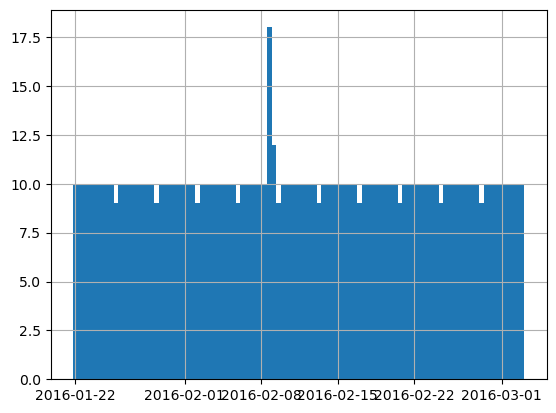

In [18]:
df['timestamp'].hist(bins = 100)


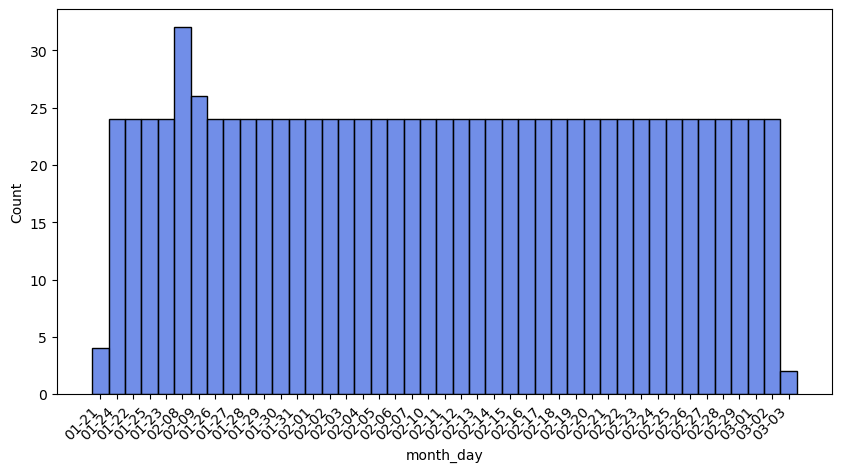

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='month_day', bins=1000, color='royalblue')


plt.xticks(rotation=45, ha = 'right')

plt.show()

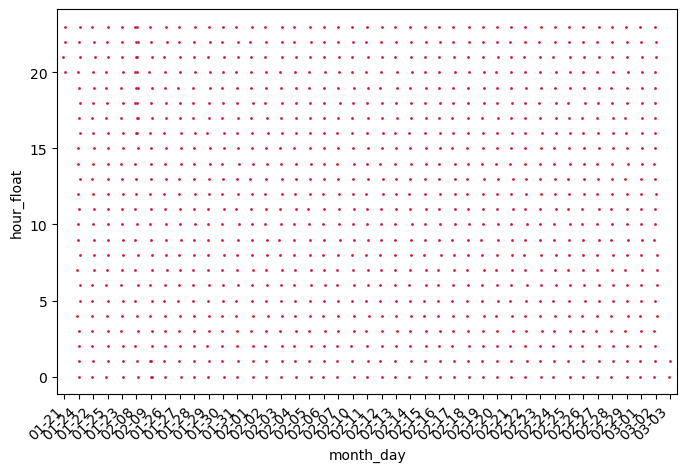

In [34]:
plt.figure(figsize=(8, 5))
sns.stripplot(data=df, x='month_day', y='hour_float', size=2, color='crimson', jitter=0.1)
plt.xticks(rotation=45, ha = 'right')

plt.show()